In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')
from ipywidgets import interact, IntSlider, VBox, HTML

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# === ЗАГРУЗКА ДАННЫХ ===
print("📁 Выбери CSV файл:")
uploaded = files.upload()
df_full = pd.read_csv(list(uploaded.keys())[0], sep=',')

# Преобразование дат
df_full['date'] = pd.to_datetime(df_full['date'], format='%d.%m.%y')
df_full = df_full.sort_values('date').reset_index(drop=True)

print(f"\n✅ Загружено {len(df_full)} матчей")
print(f"📅 Период: {df_full['date'].min().strftime('%d.%m.%Y')} - {df_full['date'].max().strftime('%d.%m.%Y')}")

# === ИНТЕРАКТИВНЫЙ ВЫБОР ЧИСЛА МАТЧЕЙ ===
def select_matches(num_matches):
    """Фильтрует DataFrame по числу матчей и сохраняет в глобальную переменную"""
    global df
    df = df_full.head(num_matches).copy()

    print(f"\n📊 Анализируем: {len(df)} матчей")
    print(f"📅 Период: {df['date'].min().strftime('%d.%m.%Y')} - {df['date'].max().strftime('%d.%m.%Y')}")

    # Показываем первые и последние матчи
    print(f"\n🔹 Первый матч: {df.iloc[0]['team_h']} vs {df.iloc[0]['team_a']} ({df.iloc[0]['date'].strftime('%d.%m.%Y')})")
    print(f"🔸 Последний матч: {df.iloc[-1]['team_h']} vs {df.iloc[-1]['team_a']} ({df.iloc[-1]['date'].strftime('%d.%m.%Y')})")

    return df

# Создаем слайдер для выбора количества матчей
slider = IntSlider(
    value=len(df_full),
    min=10,
    max=len(df_full),
    step=1,
    description='Матчей:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

# Инициализируем DataFrame всеми матчами
df = df_full.copy()

# Отображаем слайдер
output = interact(select_matches, num_matches=slider)

📁 Выбери CSV файл:


Saving wc2026_forecast.csv to wc2026_forecast (3).csv

✅ Загружено 102 матчей
📅 Период: 11.06.2026 - 15.07.2026


interactive(children=(IntSlider(value=102, continuous_update=False, description='Матчей:', max=102, min=10, st…


📊 АНАЛИЗ РАБОТЫ МОДЕЛИ (Ставка 100₽ на каждый матч стратегии)

🎯 РЕЗУЛЬТАТЫ ПО СТРАТЕГИЯМ:
-------------------------------------------------------------------------------------------------------------------
Стратегия                      | Ставок | Побед | Ср. кэф | Поставлено | Вернулось  | В кармане  | ROI     
-------------------------------------------------------------------------------------------------------------------
Все прогнозы модели            | 74     | 42    | 2.32    | 7400      ₽ | 8283.0    ₽ | +883.0    ₽ | +11.93%
Уверенные (++ >70%)            | 14     | 9     | 1.73    | 1400      ₽ | 1799.0    ₽ | +399.0    ₽ | +28.50%
Средняя уверенность (+ 50-70%) | 39     | 24    | 1.97    | 3900      ₽ | 3898.0    ₽ | -2.0      ₽ | -0.05%
Низкая уверенность (? <50%)    | 21     | 9     | 3.35    | 2100      ₽ | 2586.0    ₽ | +486.0    ₽ | +23.14%
Только валуйные ставки         | 47     | 19    | 2.89    | 4700      ₽ | 5278.0    ₽ | +578.0    ₽ | +12.30%
Валуйные + Уверенны

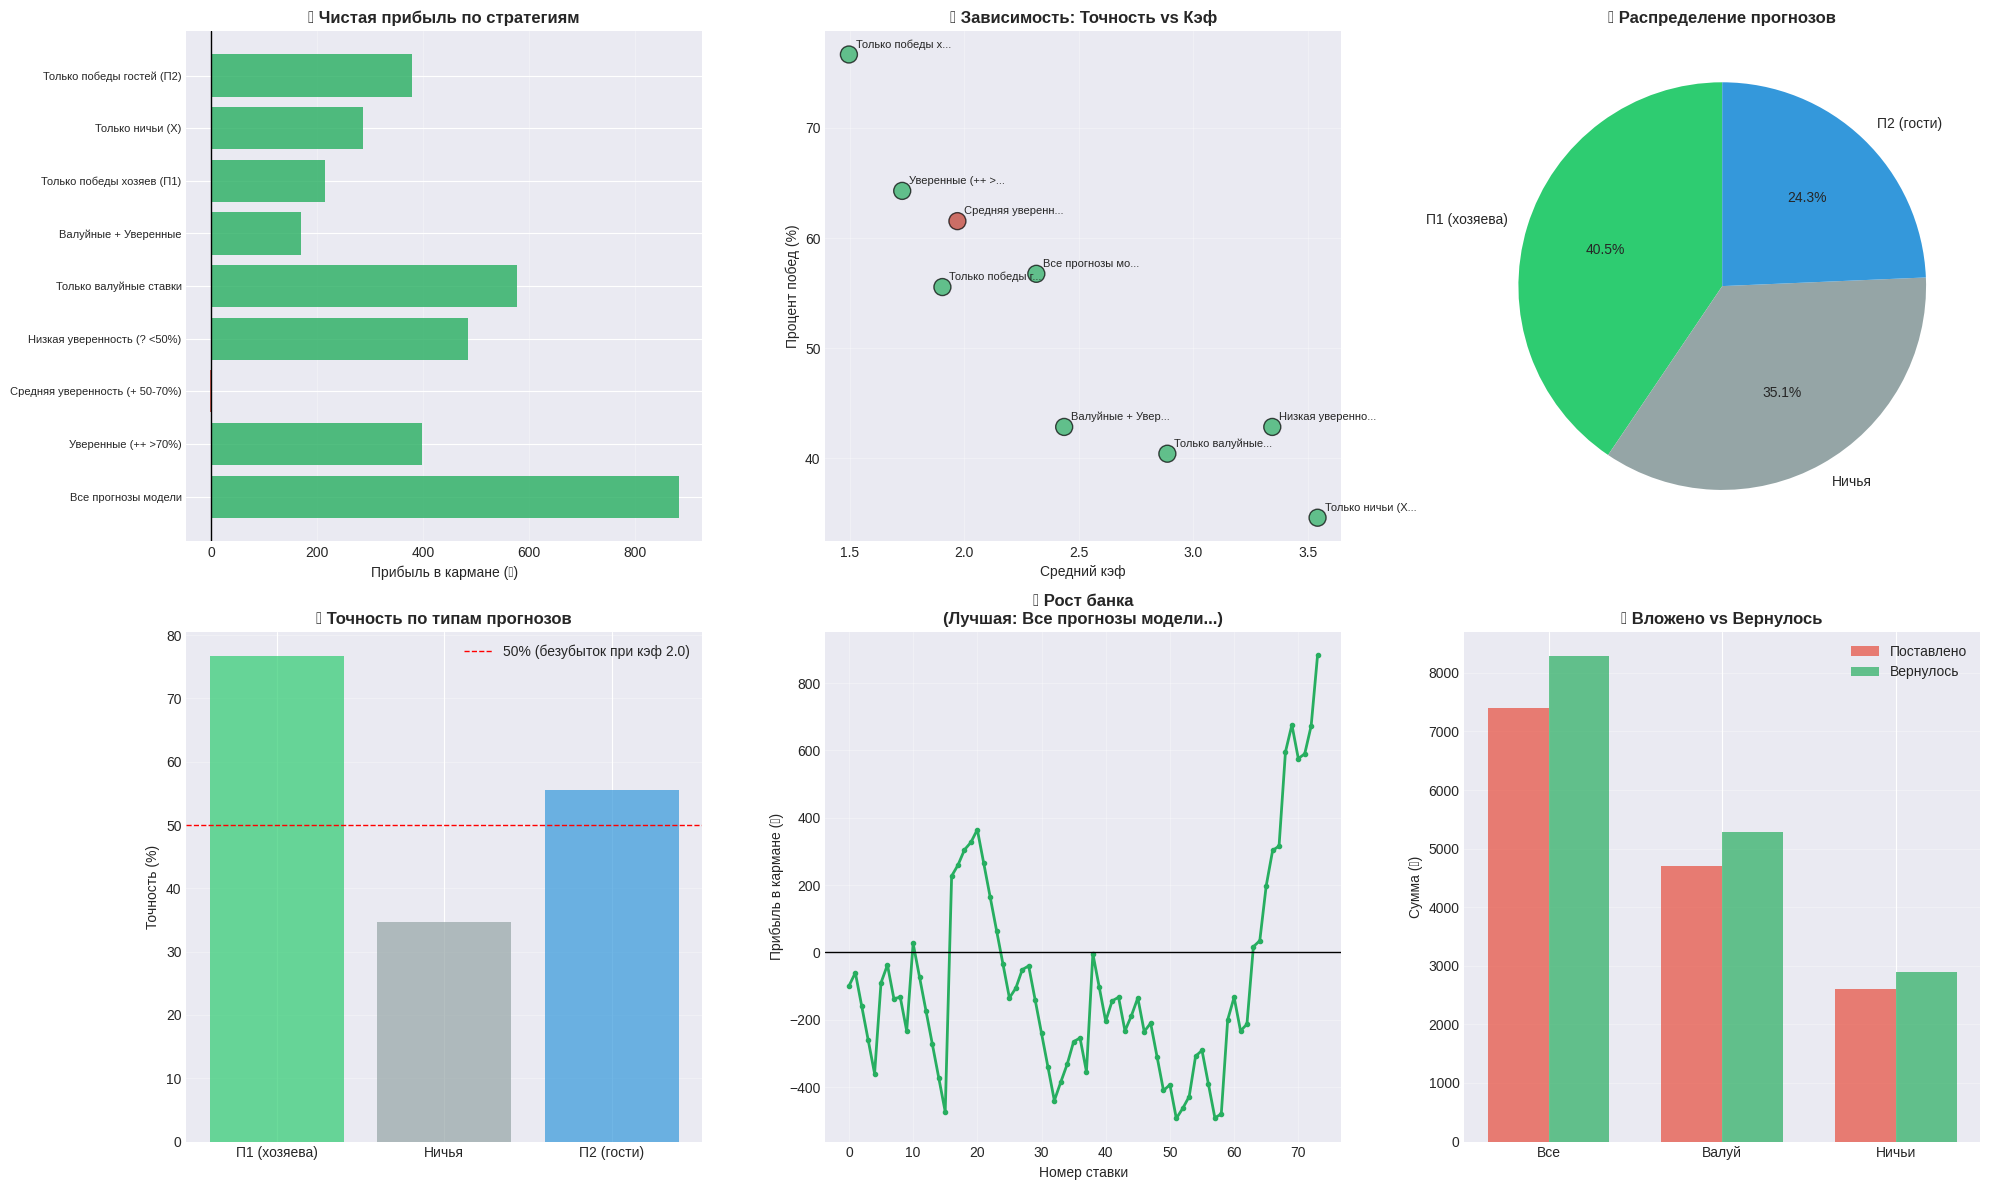


💡 ИТОГОВЫЕ ВЫВОДЫ:

🏆 ЛУЧШАЯ СТРАТЕГИЯ: Все прогнозы модели
   📊 Ставок: 74
   ✅ Побед: 42 (56.8%)
   📈 Средний кэф: 2.32
   💵 Поставлено: 7400₽
   💰 Вернулось: 8283.0₽
   💎 В кармане: +883₽
   🚀 ROI: +11.93%

📈 ОБЩАЯ ТОЧНОСТЬ МОДЕЛИ: 56.8% (42/74)

🎯 ТОЧНОСТЬ И СРЕДНИЙ КЭФ ПО ТИПАМ ПРОГНОЗОВ:
   Победа хозяев (П1)    : Точность 76.7% (23/30) | Ср. кэф: 1.50
   Ничья (Х)             : Точность 34.6% (9/26) | Ср. кэф: 3.54
   Победа гостей (П2)    : Точность 55.6% (10/18) | Ср. кэф: 1.91



In [11]:
# === ПОДГОТОВКА ДАННЫХ ===
# Вероятности букмекера из кэфов
df['bk_proba_p1'] = 1 / df['odds_p1']
df['bk_proba_x'] = 1 / df['odds_x']
df['bk_proba_p2'] = 1 / df['odds_p2']

# Нормализация вероятностей БК (сумма должна быть ~1)
bk_sum = df['bk_proba_p1'] + df['bk_proba_x'] + df['bk_proba_p2']
df['bk_proba_p1'] = df['bk_proba_p1'] / bk_sum
df['bk_proba_x'] = df['bk_proba_x'] / bk_sum
df['bk_proba_p2'] = df['bk_proba_p2'] / bk_sum

# Определение фактического результата
def get_actual_result(row):
    if row['score_h'] > row['score_a']:
        return 0  # Победа хозяев
    elif row['score_h'] == row['score_a']:
        return 1  # Ничья
    else:
        return 2  # Победа гостей

df['actual_result'] = df.apply(get_actual_result, axis=1)

# Определение уровня уверенности модели
def get_confidence_level(row):
    max_proba = max(row['proba_p1'], row['proba_x'], row['proba_p2'])
    if max_proba > 0.70:
        return '++'
    elif max_proba > 0.50:
        return '+'
    else:
        return '?'

df['confidence'] = df.apply(get_confidence_level, axis=1)

# Определение валуйности ставки
def is_value_bet(row, forecast):
    if forecast == 0:
        model_proba = row['proba_p1']
        bk_proba = row['bk_proba_p1']
    elif forecast == 1:
        model_proba = row['proba_x']
        bk_proba = row['bk_proba_x']
    else:
        model_proba = row['proba_p2']
        bk_proba = row['bk_proba_p2']

    return model_proba > bk_proba

df['is_value'] = df.apply(lambda row: is_value_bet(row, row['forecast']), axis=1)

# === ВАЖНОЕ ДОБАВЛЕНИЕ: Определяем, какой именно кэф использовала модель ===
def get_applied_odds(row):
    if row['forecast'] == 0:
        return row['odds_p1']
    elif row['forecast'] == 1:
        return row['odds_x']
    else:
        return row['odds_p2']

df['applied_odds'] = df.apply(get_applied_odds, axis=1)

# === ФУНКЦИЯ РАСЧЕТА ROI ===
def calculate_roi(df_subset, bet_amount=100):
    if len(df_subset) == 0:
        return {'bets': 0, 'wins': 0, 'losses': 0, 'total_staked': 0, 'total_returned': 0, 'profit': 0, 'roi': 0, 'win_rate': 0, 'avg_odds': 0}

    wins = 0
    total_staked = len(df_subset) * bet_amount
    total_returned = 0

    for _, row in df_subset.iterrows():
        forecast = row['forecast']
        actual = row['actual_result']
        odds = row['applied_odds'] # Берем конкретный кэф этой ставки

        if forecast == actual:
            wins += 1
            total_returned += bet_amount * odds

    losses = len(df_subset) - wins
    profit = total_returned - total_staked
    roi = (profit / total_staked * 100) if total_staked > 0 else 0
    win_rate = (wins / len(df_subset) * 100) if len(df_subset) > 0 else 0
    avg_odds = df_subset['applied_odds'].mean() # Считаем средний кэф стратегии

    return {
        'bets': len(df_subset),
        'wins': wins,
        'losses': losses,
        'total_staked': total_staked,
        'total_returned': total_returned,
        'profit': profit,
        'roi': roi,
        'win_rate': win_rate,
        'avg_odds': avg_odds
    }

# === СТРАТЕГИИ СТАВОК ===
strategies = {
    'Все прогнозы модели': df,
    'Уверенные (++ >70%)': df[df['confidence'] == '++'],
    'Средняя уверенность (+ 50-70%)': df[df['confidence'] == '+'],
    'Низкая уверенность (? <50%)': df[df['confidence'] == '?'],
    'Только валуйные ставки': df[df['is_value'] == True],
    'Валуйные + Уверенные': df[(df['is_value'] == True) & (df['confidence'].isin(['++', '+']))],
    'Только победы хозяев (П1)': df[df['forecast'] == 0],
    'Только ничьи (Х)': df[df['forecast'] == 1],
    'Только победы гостей (П2)': df[df['forecast'] == 2],
}

# Расчет ROI для каждой стратегии
results = {}
for strategy_name, df_subset in strategies.items():
    results[strategy_name] = calculate_roi(df_subset)

# === КРАСИВЫЙ ВЫВОД ===
print("\n" + "="*115)
print("📊 АНАЛИЗ РАБОТЫ МОДЕЛИ (Ставка 100₽ на каждый матч стратегии)")
print("="*115)

print("\n🎯 РЕЗУЛЬТАТЫ ПО СТРАТЕГИЯМ:")
print("-"*115)
print(f"{'Стратегия':<30} | {'Ставок':<6} | {'Побед':<5} | {'Ср. кэф':<7} | {'Поставлено':<10} | {'Вернулось':<10} | {'В кармане':<10} | {'ROI':<8}")
print("-"*115)

for strategy, stats in results.items():
    if stats['bets'] > 0:
        print(f"{strategy:<30} | {stats['bets']:<6} | {stats['wins']:<5} | {stats['avg_odds']:<7.2f} | {stats['total_staked']:<10}₽ | "
              f"{stats['total_returned']:<10}₽ | {stats['profit']:<+10}₽ | {stats['roi']:<+.2f}%")

print("-"*115)

# === ИНФОГРАФИКА ===
fig = plt.figure(figsize=(20, 12))

# График 1: Прибыль в кармане по стратегиям
ax1 = plt.subplot(2, 3, 1)
strategies_list = list(results.keys())
profit_values = [results[s]['profit'] for s in strategies_list]
colors = ['#27ae60' if p > 0 else '#c0392b' for p in profit_values]
plt.barh(range(len(strategies_list)), profit_values, color=colors, alpha=0.8)
plt.yticks(range(len(strategies_list)), strategies_list, fontsize=8)
plt.xlabel('Прибыль в кармане (₽)', fontsize=10)
plt.title('💰 Чистая прибыль по стратегиям', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', alpha=0.3)

# График 2: Win Rate vs Средний кэф (Диаграмма рассеяния)
ax2 = plt.subplot(2, 3, 2)
win_rates = [results[s]['win_rate'] for s in strategies_list]
avg_odds = [results[s]['avg_odds'] for s in strategies_list]
plt.scatter(avg_odds, win_rates, s=150, c=colors, alpha=0.7, edgecolor='black')
for i, txt in enumerate(strategies_list):
    plt.annotate(txt[:15]+'...', (avg_odds[i], win_rates[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.xlabel('Средний кэф', fontsize=10)
plt.ylabel('Процент побед (%)', fontsize=10)
plt.title('🎯 Зависимость: Точность vs Кэф', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# График 3: Распределение прогнозов модели
ax3 = plt.subplot(2, 3, 3)
forecast_counts = df['forecast'].value_counts().sort_index()
labels = ['П1 (хозяева)', 'Ничья', 'П2 (гости)']
colors_pie = ['#2ecc71', '#95a5a6', '#3498db']
plt.pie(forecast_counts.values, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
plt.title('📊 Распределение прогнозов', fontsize=12, fontweight='bold')

# График 4: Точность по типам прогнозов
ax4 = plt.subplot(2, 3, 4)
accuracy_by_forecast = []
for forecast_type in [0, 1, 2]:
    subset = df[df['forecast'] == forecast_type]
    if len(subset) > 0:
        correct = (subset['forecast'] == subset['actual_result']).sum()
        accuracy = correct / len(subset) * 100
        accuracy_by_forecast.append(accuracy)
    else:
        accuracy_by_forecast.append(0)

plt.bar(labels, accuracy_by_forecast, color=colors_pie, alpha=0.7)
plt.ylabel('Точность (%)', fontsize=10)
plt.title('🎯 Точность по типам прогнозов', fontsize=12, fontweight='bold')
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% (безубыток при кэф 2.0)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# График 5: Кумулятивная прибыль (лучшая стратегия)
ax5 = plt.subplot(2, 3, 5)
best_strategy = max(results.items(), key=lambda x: x[1]['profit'])
best_df = strategies[best_strategy[0]]

cumulative_profit = []
running_profit = 0
bet_amount = 100

for _, row in best_df.iterrows():
    if row['forecast'] == row['actual_result']:
        running_profit += bet_amount * row['applied_odds'] - bet_amount
    else:
        running_profit -= bet_amount
    cumulative_profit.append(running_profit)

plt.plot(range(len(cumulative_profit)), cumulative_profit, color='#27ae60', linewidth=2, marker='o', markersize=3)
plt.xlabel('Номер ставки', fontsize=10)
plt.ylabel('Прибыль в кармане (₽)', fontsize=10)
plt.title(f'💰 Рост банка\n(Лучшая: {best_strategy[0][:25]}...)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.grid(alpha=0.3)

# График 6: Сравнение вложено vs вернулось
ax6 = plt.subplot(2, 3, 6)
top_strategies = ['Все прогнозы модели', 'Только валуйные ставки', 'Только ничьи (Х)']
staked_values = [results[s]['total_staked'] for s in top_strategies]
returned_values = [results[s]['total_returned'] for s in top_strategies]

x = np.arange(len(top_strategies))
width = 0.35

plt.bar(x - width/2, staked_values, width, label='Поставлено', color='#e74c3c', alpha=0.7)
plt.bar(x + width/2, returned_values, width, label='Вернулось', color='#27ae60', alpha=0.7)

plt.ylabel('Сумма (₽)', fontsize=10)
plt.title('💵 Вложено vs Вернулось', fontsize=12, fontweight='bold')
plt.xticks(x, ['Все', 'Валуй', 'Ничьи'], fontsize=10)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# === ИТОГОВЫЕ ВЫВОДЫ ===
print("\n" + "="*115)
print("💡 ИТОГОВЫЕ ВЫВОДЫ:")
print("="*115)

best_strategy_name = max(results.items(), key=lambda x: x[1]['profit'])[0]
best_stats = results[best_strategy_name]

print(f"\n🏆 ЛУЧШАЯ СТРАТЕГИЯ: {best_strategy_name}")
print(f"   📊 Ставок: {best_stats['bets']}")
print(f"   ✅ Побед: {best_stats['wins']} ({best_stats['win_rate']:.1f}%)")
print(f"   📈 Средний кэф: {best_stats['avg_odds']:.2f}")
print(f"   💵 Поставлено: {best_stats['total_staked']}₽")
print(f"   💰 Вернулось: {best_stats['total_returned']}₽")
print(f"   💎 В кармане: {best_stats['profit']:+.0f}₽")
print(f"   🚀 ROI: {best_stats['roi']:+.2f}%")

total_correct = (df['forecast'] == df['actual_result']).sum()
total_accuracy = total_correct / len(df) * 100

print(f"\n📈 ОБЩАЯ ТОЧНОСТЬ МОДЕЛИ: {total_accuracy:.1f}% ({total_correct}/{len(df)})")

print(f"\n🎯 ТОЧНОСТЬ И СРЕДНИЙ КЭФ ПО ТИПАМ ПРОГНОЗОВ:")
for forecast_type, label in [(0, "Победа хозяев (П1)"), (1, "Ничья (Х)"), (2, "Победа гостей (П2)")]:
    subset = df[df['forecast'] == forecast_type]
    if len(subset) > 0:
        correct = (subset['forecast'] == subset['actual_result']).sum()
        accuracy = correct / len(subset) * 100
        avg_odds_type = subset['applied_odds'].mean()
        print(f"   {label:<22}: Точность {accuracy:.1f}% ({correct}/{len(subset)}) | Ср. кэф: {avg_odds_type:.2f}")

print("\n" + "="*115)